In [1]:
# Import pandas and numpy libraries

import pandas as pd
import numpy as np

In [2]:
# Read train data from csv file

train_df = pd.read_csv('train.csv')
train_df.head()

,FlightDate,Airline,Origin,Dest,CRSDepTime,Distance,Year,Month,DayofMonth,DayOfWeek,...,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DCD
0,2020-11-21,Southwest Airlines Co.,MCI,TPA,1450,1048.0,2020,11,21,6,...,64,15304,1530402,33195,"Tampa, FL",FL,12,Florida,33,False
1,2021-01-14,Delta Air Lines Inc.,ATL,PHX,1959,1587.0,2021,1,14,4,...,34,14107,1410702,30466,"Phoenix, AZ",AZ,4,Arizona,81,False
2,2021-11-05,"GoJet Airlines, LLC d/b/a United Express",DCA,EWR,1830,199.0,2021,11,5,5,...,38,11618,1161802,31703,"Newark, NJ",NJ,34,New Jersey,21,False
3,2019-07-09,Republic Airlines,DCA,ORD,1545,612.0,2019,7,9,2,...,38,13930,1393007,30977,"Chicago, IL",IL,17,Illinois,41,False
4,2021-08-17,Capital Cargo International,CLE,ORD,1235,315.0,2021,8,17,2,...,44,13930,1393007,30977,"Chicago, IL",IL,17,Illinois,41,False


In [3]:
# In the example, we will use a reduced version of the data, with just 3 variables

X= train_df[['Marketing_Airline_Network',
             'Distance',
             'OriginState']].copy()

y = train_df[['DCD']]

In [4]:
# Airline and Origin are not numerical variables, we will encode them later using trainig data

X[['Marketing_Airline_Network']].nunique(), X[['OriginState']].nunique()

(Marketing_Airline_Network    10
 dtype: int64,
 OriginState    53
 dtype: int64)

In [5]:
from sklearn.model_selection import train_test_split

# Create a random 20% split for validation
# X_ subsets are for input variables
# y_ subsets are for targets

X_train, X_val, y_train, y_val = train_test_split(X.fillna(0), 
                                                  y, 
                                                  test_size=0.2, 
                                                  random_state=2023)

X.shape, X_train.shape, X_val.shape, y_train.shape, y_val.shape

((1554077, 3), (1243261, 3), (310816, 3), (1243261, 1), (310816, 1))

In [6]:
# Since Marketing_Airline_Network, and OriginState are categorical variable, we define a function for
# applying OHE and drop the original variables
# We'll use the scikit-learn OneHotEncoder:

from sklearn.preprocessing import OneHotEncoder

# This function creates the encoding. We will use it with our training set.

# The function has two parameters:
# - df_in: input dataframe, in our case, the training dataset
# - variable: the variable we want to convert from categorical to a set of binaries

# This function returns two things:
# - Our transformed dataset, including the binary variables instead of the categorical
# - The encoder so we can apply the same transformation later with our test dataset

def fun_ohe (df_in, variable):
    
    ohe = OneHotEncoder(sparse=False)
    ohe.fit(df_in[[variable]])
    ohe_df = pd.DataFrame(ohe.transform(df_in[[variable]]),
                 columns = ohe.get_feature_names_out([variable]))
    ohe_df.set_index(df_in.index, inplace=True)
    return pd.concat([df_in, ohe_df], axis=1).drop([variable], axis=1), ohe

# This function applies a previously created encoder. We will use it with our test set.

# The function has three parameters:
# - df_in: input dataframe, in our case, the training dataset
# - variable: the variable we want to convert from categorical to a set of binaries
# - encoder: the encoder that we want to use (the one we created with fun_ohe()

# This function returns:
# - Our transformed dataset, including the binary variables instead of the categorical

def apply_fun_ohe (df_in, variable, encoder):
    
    ohe_df = pd.DataFrame(encoder.transform(df_in[[variable]]),
                 columns = encoder.get_feature_names_out([variable]))
    ohe_df.set_index(df_in.index, inplace=True)
    return pd.concat([df_in, ohe_df], axis=1).drop([variable], axis=1)

X_train, encoder_Marketing_Airline_Network = fun_ohe (X_train, 'Marketing_Airline_Network')
X_train, encoder_OriginState = fun_ohe (X_train, 'OriginState')

In [7]:
# We just apply the same One Hot Encoder to the validation set

X_val = apply_fun_ohe (X_val, 'Marketing_Airline_Network', encoder_Marketing_Airline_Network)
X_val = apply_fun_ohe (X_val, 'OriginState', encoder_OriginState)

In [8]:
# We can see now how we don't have anymore categorical variables, but binary and numerical
X_train.head(2)

,Distance,Marketing_Airline_Network_AA,Marketing_Airline_Network_AS,Marketing_Airline_Network_B6,Marketing_Airline_Network_DL,Marketing_Airline_Network_F9,Marketing_Airline_Network_G4,Marketing_Airline_Network_HA,Marketing_Airline_Network_NK,Marketing_Airline_Network_UA,...,OriginState_TT,OriginState_TX,OriginState_UT,OriginState_VA,OriginState_VI,OriginState_VT,OriginState_WA,OriginState_WI,OriginState_WV,OriginState_WY
936298,2704.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
487245,425.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
# Same for the validation set
X_val.head(2)

,Distance,Marketing_Airline_Network_AA,Marketing_Airline_Network_AS,Marketing_Airline_Network_B6,Marketing_Airline_Network_DL,Marketing_Airline_Network_F9,Marketing_Airline_Network_G4,Marketing_Airline_Network_HA,Marketing_Airline_Network_NK,Marketing_Airline_Network_UA,...,OriginState_TT,OriginState_TX,OriginState_UT,OriginState_VA,OriginState_VI,OriginState_VT,OriginState_WA,OriginState_WI,OriginState_WV,OriginState_WY
618587,509.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
226733,1042.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
# Let's try now to fit a Random Forest model to the train subset.
# If you are not familiar with Random Forest, just ask! :)

# We'll iterate through different number of estimators, features, and max_depth, 
# then train the model and save its RMSE result for the training dataset
# and then apply it to the validation subset and save its RMSE too:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import brier_score_loss

result_train_dict = {} # We'll use a dictionary to save the results for the training set
result_val_dict = {}   # We'll use a dictionary to save the results for the validation set

max_depth = 4 # Max depth of each of the decision trees used in the RF
max_samples= 0.8 # Use 80% or less of the data for training each tree
max_features= 0.8 # Use 80% or less of the variables for each tree

n_estimators= [1, 10, 20, 30, 40, 50] # Number of trees in the forest

for n in n_estimators:
    
    print(n)

    tree_reg = RandomForestClassifier(random_state= 2023, 
                                     n_estimators= n, 
                                     max_depth= max_depth,
                                     max_features= max_features,
                                     bootstrap= True,
                                     max_samples= max_samples)

    tree_reg.fit(X_train, np.ravel(y_train)) # Fit the model to the train subset

    train_predicted = tree_reg.predict_proba(X_train)[:,1] # Apply the model to train. Predict_proba gets us both the probability of 0 and 1. We want the
                                                            # probability of events labeled as 1, so we take the column #1 (not #0)
    val_predicted = tree_reg.predict_proba(X_val)[:,1] # Apply the model to validation

    result_train_dict[n] = brier_score_loss(y_train, train_predicted) # Save train score
    result_val_dict[n] = brier_score_loss(y_val, val_predicted) # Save validation score

1
10
20
30
40
50


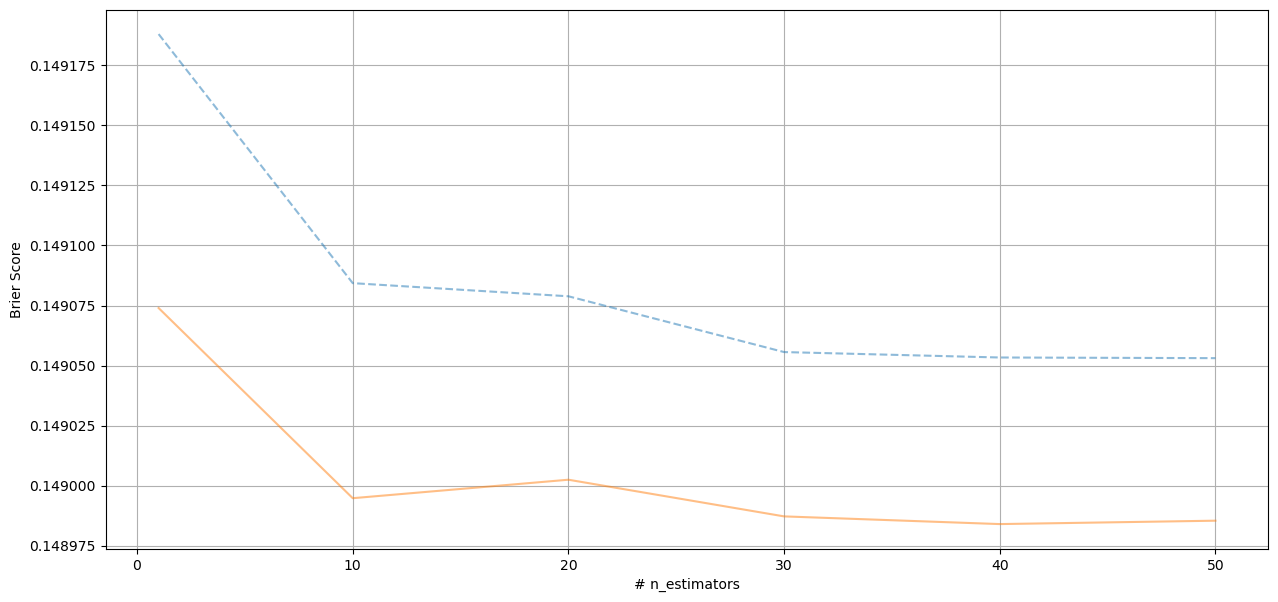

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# We can plot the results for both train and validation sets.
# The more trees we train, the less RMSE. Sounds good, right?

fig, ax = plt.subplots(figsize=(15, 7))

line_plot_train = []
line_plot_val = []
n_estimators= [1, 10, 20, 30, 40, 50]

for m in n_estimators:
    
    line_plot_train.append(result_train_dict.get(m))
    line_plot_val.append(result_val_dict.get(m))

plt.plot(n_estimators, 
         line_plot_train, alpha=0.5, linestyle='--')

plt.plot(n_estimators, 
         line_plot_val, alpha=0.5)

ax.grid(True)
plt.xlabel('# n_estimators')
plt.ylabel('Brier Score')

plt.show()

In [12]:
# Once we have chosen our parameters, in this case that we want to use 50 trees,
# we can use both train and validation (see pd.concat) for training the final model:

tree_reg = RandomForestClassifier(random_state=2023, 
                                 n_estimators= 50,
                                 max_depth= 4,
                                 max_features= 0.8,
                                 max_samples= 0.8,
                                 bootstrap= True)

tree_reg.fit(pd.concat([X_train, X_val]), np.ravel(y))
train_predicted = tree_reg.predict_proba(pd.concat([X_train, X_val]))[:,1]

# And we should get a similar RMSE
brier_score_loss(y, train_predicted)

0.15030093988423282

In [13]:
# Now, to apply our model to the test data we need to repeat the process:
# Read the data

test_df = pd.read_csv('test.csv')
test_df.head()

,FlightDate,Airline,Origin,Dest,CRSDepTime,Distance,Year,Month,DayofMonth,DayOfWeek,...,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,id
0,2020-07-21,Delta Air Lines Inc.,DTW,RSW,1230,1084.0,2020,7,21,2,...,43,14635,1463502,31714,"Fort Myers, FL",FL,12,Florida,33,672640
1,2021-01-09,Southwest Airlines Co.,HNL,KOA,1400,163.0,2021,1,9,6,...,2,12758,1275804,32758,"Kona, HI",HI,15,Hawaii,2,792812
2,2020-10-05,SkyWest Airlines Inc.,ORD,MKG,1620,119.0,2020,10,5,1,...,41,13344,1334403,33344,"Muskegon, MI",MI,26,Michigan,43,316770
3,2021-03-11,Spirit Air Lines,DFW,DTW,700,986.0,2021,3,11,4,...,74,11433,1143302,31295,"Detroit, MI",MI,26,Michigan,43,363303
4,2021-12-11,SkyWest Airlines Inc.,SBN,DFW,1633,846.0,2021,12,11,6,...,42,11298,1129806,30194,"Dallas/Fort Worth, TX",TX,48,Texas,74,247295


In [14]:
# Keep just the variables that we used for training

X_test= test_df[['id',
                 'Marketing_Airline_Network',
                 'Distance',
                 'OriginState']].copy()

X_test.set_index('id', inplace=True)
X_test.head()

,Marketing_Airline_Network,Distance,OriginState
id,,,
672640,DL,1084.0,MI
792812,WN,163.0,HI
316770,UA,119.0,IL
363303,NK,986.0,TX
247295,AA,846.0,IN


In [15]:
# Apply the same transformations

X_test = apply_fun_ohe (X_test, 'Marketing_Airline_Network', encoder_Marketing_Airline_Network)
X_test = apply_fun_ohe (X_test, 'OriginState', encoder_OriginState)

In [16]:
X_test.head()

,Distance,Marketing_Airline_Network_AA,Marketing_Airline_Network_AS,Marketing_Airline_Network_B6,Marketing_Airline_Network_DL,Marketing_Airline_Network_F9,Marketing_Airline_Network_G4,Marketing_Airline_Network_HA,Marketing_Airline_Network_NK,Marketing_Airline_Network_UA,...,OriginState_TT,OriginState_TX,OriginState_UT,OriginState_VA,OriginState_VI,OriginState_VT,OriginState_WA,OriginState_WI,OriginState_WV,OriginState_WY
id,,,,,,,,,,,,,,,,,,,,,
672640,1084.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
792812,163.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
316770,119.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
363303,986.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
247295,846.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
# Apply the already trained RF to our test dataset:

y_test = X_test[[]].copy()
y_test['DCD'] = tree_reg.predict_proba(X_test)[:,1]
y_test.head()

,DCD
id,
672640,0.184054
792812,0.185023
316770,0.184162
363303,0.184199
247295,0.184359


In [18]:
# And create the .csv file with the predictions!
# Do we get a better score than the sample submission? Can we do even better?

y_test.to_csv('RF_submission.csv', index=True)

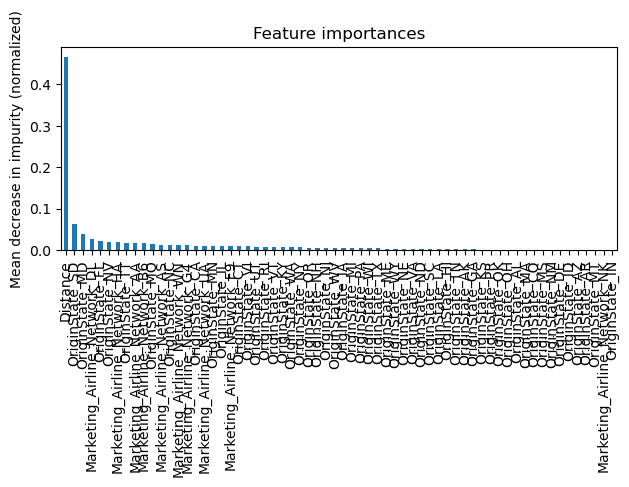

In [19]:
# We can even take a look at our variable importance and see which ones are driving our
# model's predictions. It looks like distance is a powerful variable!

feat_importance = tree_reg.feature_importances_
tree_importances = pd.Series(feat_importance, index=X_test.columns).sort_values(ascending=False)

fig, ax = plt.subplots()
tree_importances.plot.bar(ax=ax)
ax.set_title("Feature importances")
ax.set_ylabel("Mean decrease in impurity (normalized)")
fig.tight_layout()